In [1208]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Data Inspection and Analysis

In [1209]:
df = pd.read_csv("train.csv")
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [1210]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [1211]:
# Extract the Title (Mr, Mrs, Miss, Master, Rare) from the Name before dropping it
def extract_title(name):
    title = name.split(",")[1].split(".")[0].strip()
    title = {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"}.get(title, title)
    if title not in {"Mr", "Mrs", "Miss", "Master"}:
        title = "Rare"
    return title

df["Title"] = df["Name"].apply(extract_title)

# Remove the Name column now that the Title is extracted
df.drop("Name", axis = 1, inplace = True)

In [1212]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [1213]:
# Let's replace the missing ages with average male and female ages
age_male = df[df["Sex"] == "male"]["Age"].mean()
age_female = df[df["Sex"] == "female"]["Age"].mean()

df.loc[df["Sex"] == "male", "Age"] = df.loc[df["Sex"] == "male", "Age"].fillna(age_male)
df.loc[df["Sex"] == "female", "Age"] = df.loc[df["Sex"] == "female", "Age"].fillna(age_female)

# Most of the Embarked column is S, so replace missing values with S
df["Embarked"] = df["Embarked"].fillna("S")

In [1214]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S,Mr


In [1215]:
# Family features
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df["Fare_Per_Person"] = df["Fare"] / df["FamilySize"]

<Axes: xlabel='Fare_Per_Person', ylabel='Count'>

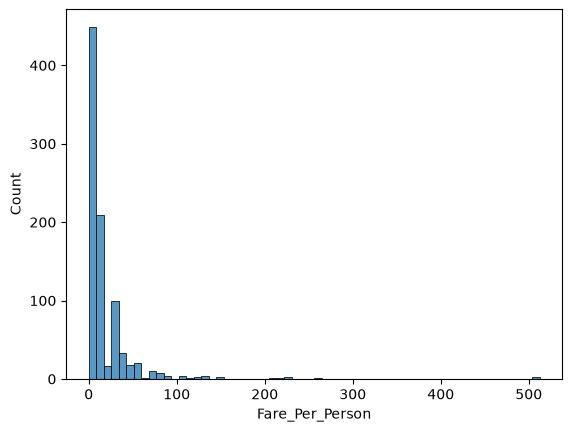

In [1216]:
sns.histplot(data = df, x = "Fare_Per_Person")

In [1217]:
df["Fare_Per_Person"] = np.log1p(df["Fare_Per_Person"])

df["IsChild"] = (df["Age"] < 16).astype(int)

df["is_male"] = (df["Sex"] == "male").astype(int)
df["Sex_Pclass"] = df["is_male"] * df["Pclass"]
df["Age_Pclass"] = df["Age"] * df["Pclass"]

df.drop(["SibSp", "Parch", "Fare", "Sex"], axis = 1, inplace = True)

<Axes: xlabel='Fare_Per_Person', ylabel='Count'>

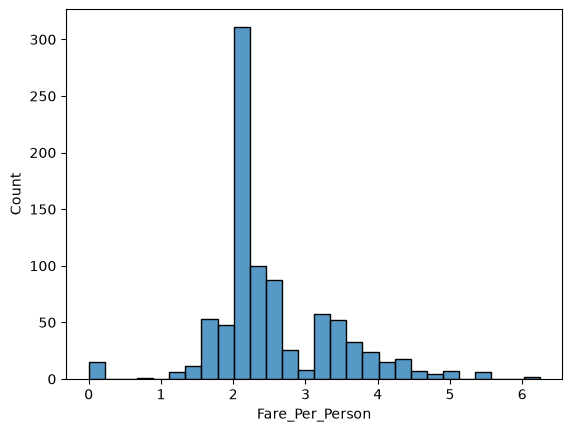

In [1218]:
sns.histplot(data = df, x = "Fare_Per_Person")

In [1219]:
df["HasCabin"] = df["Cabin"].notna().astype(int)
df.drop("Cabin", axis = 1, inplace = True)

In [1220]:
df = pd.get_dummies(df, columns = ["Embarked", "Title", "Pclass"])

In [1221]:
df

,PassengerId,Survived,Age,Ticket,FamilySize,IsAlone,Fare_Per_Person,IsChild,is_male,Sex_Pclass,...,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Pclass_1,Pclass_2,Pclass_3
0,1,0,22.000000,A/5 21171,2,0,1.531476,0,1,3,...,False,True,False,False,True,False,False,False,False,True
1,2,1,38.000000,PC 17599,2,0,3.601186,0,0,0,...,False,False,False,False,False,True,False,True,False,False
2,3,1,26.000000,STON/O2. 3101282,1,1,2.188856,0,0,0,...,False,True,False,True,False,False,False,False,False,True
3,4,1,35.000000,113803,2,0,3.316003,0,0,0,...,False,True,False,False,False,True,False,True,False,False
4,5,0,35.000000,373450,1,1,2.202765,0,1,3,...,False,True,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,27.000000,211536,1,1,2.639057,0,1,2,...,False,True,False,False,False,False,True,False,True,False
887,888,1,19.000000,112053,1,1,3.433987,0,0,0,...,False,True,False,True,False,False,False,True,False,False
888,889,0,27.915709,W./C. 6607,4,0,1.926072,0,0,0,...,False,True,False,True,False,False,False,False,False,True
889,890,1,26.000000,111369,1,1,3.433987,0,1,1,...,False,False,False,False,True,False,False,True,False,False


# 2. Prediction Model

In [1222]:
X = df.drop(["PassengerId", "Ticket", "Survived"], axis = 1)
y = df["Survived"]

linear_model = LinearRegression()
linear_model.fit(X, y)

best_threshold = 0.5
train_acc = ((linear_model.predict(X) > best_threshold).astype(int) == y).mean()
print(f"Train accuracy at threshold {best_threshold}: {train_acc:.3f}")

Train accuracy at threshold 0.5: 0.836


In [1223]:
df_test = pd.read_csv("test.csv")

In [1224]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [1225]:
# Fill missing Fare values with the mean
mean_fare = df_test["Fare"].mean()
df_test["Fare"] = df_test["Fare"].fillna(mean_fare)
df_test.loc[df_test["Sex"] == "male", "Age"] = df_test.loc[df_test["Sex"] == "male", "Age"].fillna(age_male)
df_test.loc[df_test["Sex"] == "female", "Age"] = df_test.loc[df_test["Sex"] == "female", "Age"].fillna(age_female)

In [1226]:
# Family features
df_test["FamilySize"] = df_test["SibSp"] + df_test["Parch"] + 1
df_test["IsAlone"] = (df_test["FamilySize"] == 1).astype(int)

# Per-person fare 
df_test["Fare_Per_Person"] = df_test["Fare"] / df_test["FamilySize"]
df_test["Fare_Per_Person"] = np.log1p(df_test["Fare_Per_Person"])

df_test["IsChild"] = (df_test["Age"] < 16).astype(int)

df_test["is_male"] = (df_test["Sex"] == "male").astype(int)
df_test["Sex_Pclass"] = df_test["is_male"] * df_test["Pclass"]
df_test["Age_Pclass"] = df_test["Age"] * df_test["Pclass"]

df_test.drop(["SibSp", "Parch", "Fare", "Sex"], axis = 1, inplace = True)

In [1227]:
df_test["HasCabin"] = df_test["Cabin"].notna().astype(int)
df_test["Title"] = df_test["Name"].apply(extract_title)
df_test.drop(["Cabin", "Name"], axis = 1, inplace = True)
df_test = pd.get_dummies(df_test, columns = ["Embarked", "Title", "Pclass"])

In [1228]:
df_test.head()

,PassengerId,Age,Ticket,FamilySize,IsAlone,Fare_Per_Person,IsChild,is_male,Sex_Pclass,Age_Pclass,...,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Pclass_1,Pclass_2,Pclass_3
0,892,34.5,330911,1,1,2.178064,0,1,3,103.5,...,True,False,False,False,True,False,False,False,False,True
1,893,47.0,363272,2,0,1.504077,0,0,0,141.0,...,False,True,False,False,False,True,False,False,False,True
2,894,62.0,240276,1,1,2.369075,0,1,2,124.0,...,True,False,False,False,True,False,False,False,True,False
3,895,27.0,315154,1,1,2.268252,0,1,3,81.0,...,False,True,False,False,True,False,False,False,False,True
4,896,22.0,3101298,3,0,1.628423,0,0,0,66.0,...,False,True,False,False,False,True,False,False,False,True


In [1229]:
X_test = df_test.drop(["PassengerId", "Ticket"], axis = 1)
X_test = X_test.reindex(columns=X.columns, fill_value=0)
test_pred = linear_model.predict(X_test) > best_threshold

In [1230]:
test_pred = test_pred.astype(int)

In [1231]:
submission_data = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": test_pred
})

In [1232]:
submission_data.to_csv("output.csv", index=False)